# Habitat 2.0 Benchmarking

Mirrors the official `scripts/hab2_bench/bench_runner.sh` from habitat-lab v0.3.3.
Three configs (idle 4-sensor, idle single-camera, interact) × three ablations (all / no-concur / no-sleep) × 3 trials at n_procs=1.

## 1. Setup: symlinks, episode dataset, EGL

In [1]:
%%bash
# Symlink hab2 benchmark assets from Drive
mkdir -p /content/data /content/data/robots
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/hab2_bench_assets_1.0 /content/data/hab2_bench_assets
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/hab_fetch /content/data/robots/hab_fetch
ln -sfn /content/data /content/habitat-lab-v033/data 2>/dev/null || true

# Copy pre-generated bench episode into ep_datasets/
mkdir -p /content/data/ep_datasets
cp -n /content/data/hab2_bench_assets/bench_scene.json.gz /content/data/ep_datasets/bench_scene.json.gz
ls -lh /content/data/ep_datasets/bench_scene.json.gz

# Sanity check the fetch URDF the demo configs need
ls -lh /content/data/robots/hab_fetch/robots/fetch_no_base.urdf 2>&1 | head -1

# EGL ICD (same as hab3 setup)
cat > /tmp/nvidia_egl.json << 'EOF'
{"file_format_version":"1.0.0","ICD":{"library_path":"libEGL_nvidia.so.0"}}
EOF
echo Ready

-rw------- 1 root root 1.7K Apr 28 05:46 /content/data/ep_datasets/bench_scene.json.gz
-rw------- 1 root root 18K Apr 16 04:28 /content/data/robots/hab_fetch/robots/fetch_no_base.urdf
Ready


## 2. Inspect benchmark configs

In [5]:
%%bash
ls /content/habitat-lab-v033/habitat-lab/habitat/config/benchmark/rearrange/demo/

idle_single_camera.yaml
idle.yaml
interact.yaml


## 3. Benchmark 1: Idle, 4 sensors (arm + head RGBD)
Runs three ablations × three trials each: defaults / `concur_render=False` / `auto_sleep=False`.

In [6]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

mkdir -p data/profile
NUM_STEPS=200
CFG=benchmark/rearrange/demo/idle.yaml

for i in 1 2 3; do
  echo "=== idle trial $i: all ==="
  python scripts/hab2_bench/hab2_benchmark.py --cfg $CFG --n-steps $NUM_STEPS --n-procs 1 --out-name "all_$i" 2>&1 | tail -3
  echo "=== idle trial $i: noconcur ==="
  python scripts/hab2_bench/hab2_benchmark.py --cfg $CFG --n-steps $NUM_STEPS --n-procs 1 --out-name "noconcur_$i" habitat.simulator.concur_render=False 2>&1 | tail -3
  echo "=== idle trial $i: nosleep ==="
  python scripts/hab2_bench/hab2_benchmark.py --cfg $CFG --n-steps $NUM_STEPS --n-procs 1 --out-name "nosleep_$i" habitat.simulator.auto_sleep=False 2>&1 | tail -3
done
ls -1 data/profile/ | grep '^1_200_-1_idle_'

=== idle trial 1: all ===
Ran 1 trial(s) with average FPS of 259.09008949163905 from [259.09008949163905].
=== idle trial 1: noconcur ===
Ran 1 trial(s) with average FPS of 270.7351648397986 from [270.7351648397986].
=== idle trial 1: nosleep ===
Ran 1 trial(s) with average FPS of 202.2055990451113 from [202.2055990451113].
=== idle trial 2: all ===
Ran 1 trial(s) with average FPS of 253.4075671927405 from [253.4075671927405].
=== idle trial 2: noconcur ===
Ran 1 trial(s) with average FPS of 200.87662835249043 from [200.87662835249043].
=== idle trial 2: nosleep ===
Ran 1 trial(s) with average FPS of 207.98878853815415 from [207.98878853815415].
=== idle trial 3: all ===
Ran 1 trial(s) with average FPS of 253.45881652725922 from [253.45881652725922].
=== idle trial 3: noconcur ===
Ran 1 trial(s) with average FPS of 269.46969966498153 from [269.46969966498153].
=== idle trial 3: nosleep ===
Ran 1 trial(s) with average FPS of 205.81794921934238 from [205.81794921934238].
1_200_-1_idle_al

## 4. Benchmark 2: Idle, 1 sensor (head RGB)

In [7]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

NUM_STEPS=200
CFG=benchmark/rearrange/demo/idle_single_camera.yaml

for i in 1 2 3; do
  echo "=== idle_single_camera trial $i: all ==="
  python scripts/hab2_bench/hab2_benchmark.py --cfg $CFG --n-steps $NUM_STEPS --n-procs 1 --out-name "all_$i" 2>&1 | tail -3
  echo "=== idle_single_camera trial $i: noconcur ==="
  python scripts/hab2_bench/hab2_benchmark.py --cfg $CFG --n-steps $NUM_STEPS --n-procs 1 --out-name "noconcur_$i" habitat.simulator.concur_render=False 2>&1 | tail -3
  echo "=== idle_single_camera trial $i: nosleep ==="
  python scripts/hab2_bench/hab2_benchmark.py --cfg $CFG --n-steps $NUM_STEPS --n-procs 1 --out-name "nosleep_$i" habitat.simulator.auto_sleep=False 2>&1 | tail -3
done
ls -1 data/profile/ | grep '^1_200_-1_idle_single_camera_'

=== idle_single_camera trial 1: all ===
Ran 1 trial(s) with average FPS of 409.32139566200965 from [409.32139566200965].
=== idle_single_camera trial 1: noconcur ===
Ran 1 trial(s) with average FPS of 415.9236826395346 from [415.9236826395346].
=== idle_single_camera trial 1: nosleep ===
Ran 1 trial(s) with average FPS of 284.9722070100446 from [284.9722070100446].
=== idle_single_camera trial 2: all ===
Ran 1 trial(s) with average FPS of 397.0890524714279 from [397.0890524714279].
=== idle_single_camera trial 2: noconcur ===
Ran 1 trial(s) with average FPS of 500.587448286947 from [500.587448286947].
=== idle_single_camera trial 2: nosleep ===
Ran 1 trial(s) with average FPS of 294.0495800104491 from [294.0495800104491].
=== idle_single_camera trial 3: all ===
Ran 1 trial(s) with average FPS of 416.6043986046412 from [416.6043986046412].
=== idle_single_camera trial 3: noconcur ===
Ran 1 trial(s) with average FPS of 507.3892604475806 from [507.3892604475806].
=== idle_single_camera tr

## 5. Benchmark 3: Interact, 4 sensors
Agent picks/places objects (heavier physics workload).

In [8]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

NUM_STEPS=200
CFG=benchmark/rearrange/demo/interact.yaml

for i in 1 2 3; do
  echo "=== interact trial $i: all ==="
  python scripts/hab2_bench/hab2_benchmark.py --cfg $CFG --n-steps $NUM_STEPS --n-procs 1 --out-name "all_$i" 2>&1 | tail -3
  echo "=== interact trial $i: noconcur ==="
  python scripts/hab2_bench/hab2_benchmark.py --cfg $CFG --n-steps $NUM_STEPS --n-procs 1 --out-name "noconcur_$i" habitat.simulator.concur_render=False 2>&1 | tail -3
  echo "=== interact trial $i: nosleep ==="
  python scripts/hab2_bench/hab2_benchmark.py --cfg $CFG --n-steps $NUM_STEPS --n-procs 1 --out-name "nosleep_$i" habitat.simulator.auto_sleep=False 2>&1 | tail -3
done
ls -1 data/profile/ | grep '^1_200_-1_interact_'

=== interact trial 1: all ===
Ran 1 trial(s) with average FPS of 91.30478162218147 from [91.30478162218147].
=== interact trial 1: noconcur ===
Ran 1 trial(s) with average FPS of 127.36721027145549 from [127.36721027145549].
=== interact trial 1: nosleep ===
Ran 1 trial(s) with average FPS of 126.82900417836821 from [126.82900417836821].
=== interact trial 2: all ===
Ran 1 trial(s) with average FPS of 147.25307321754795 from [147.25307321754795].
=== interact trial 2: noconcur ===
Ran 1 trial(s) with average FPS of 115.64182486716312 from [115.64182486716312].
=== interact trial 2: nosleep ===
Ran 1 trial(s) with average FPS of 147.04232512016043 from [147.04232512016043].
=== interact trial 3: all ===
Ran 1 trial(s) with average FPS of 147.99085458884923 from [147.99085458884923].
=== interact trial 3: noconcur ===
Ran 1 trial(s) with average FPS of 96.78708884708696 from [96.78708884708696].
=== interact trial 3: nosleep ===
Ran 1 trial(s) with average FPS of 147.68657764066043 from 

## 6. Plot results with plot_bench.py
Patches the official script to skip `n_procs=16` (we only ran 1), then runs it. Output: `data/profile/opts_1.pdf`.

In [9]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
unset MPLBACKEND
export MPLBACKEND=Agg

curl -fsSL "https://raw.githubusercontent.com/facebookresearch/habitat-lab/v0.3.3/scripts/hab2_bench/plot_bench.py" \
  -o scripts/hab2_bench/plot_bench.py

python3 - <<'PY'
import re
p = "scripts/hab2_bench/plot_bench.py"
s = open(p).read()
s = re.sub(r"for i in \[1, 16\]:", "for i in [1]:", s)
open(p, "w").write(s)
print("patched")
PY

python scripts/hab2_bench/plot_bench.py
ls -lh data/profile/opts_*.pdf

patched
[Idle]: 255&{\scriptsize$\pm$3}

[Idle No Concurrent Rendering]: 247&{\scriptsize$\pm$42}

[Idle No Auto-sleep]: 205&{\scriptsize$\pm$3}

[Idle (head-RGB)]: 408&{\scriptsize$\pm$10}

[Idle (head-RGB) No Concurrent Rendering]: 475&{\scriptsize$\pm$54}

[Idle (head-RGB) No Auto-sleep]: 279&{\scriptsize$\pm$20}

[Interact]: 129&{\scriptsize$\pm$34}

[Interact No Concurrent Rendering]: 113&{\scriptsize$\pm$16}

[Interact No Auto-sleep]: 141&{\scriptsize$\pm$12}

-rw-r--r-- 1 root root 16K Apr 28 03:39 data/profile/opts_1.pdf


## 7. View the plot inline

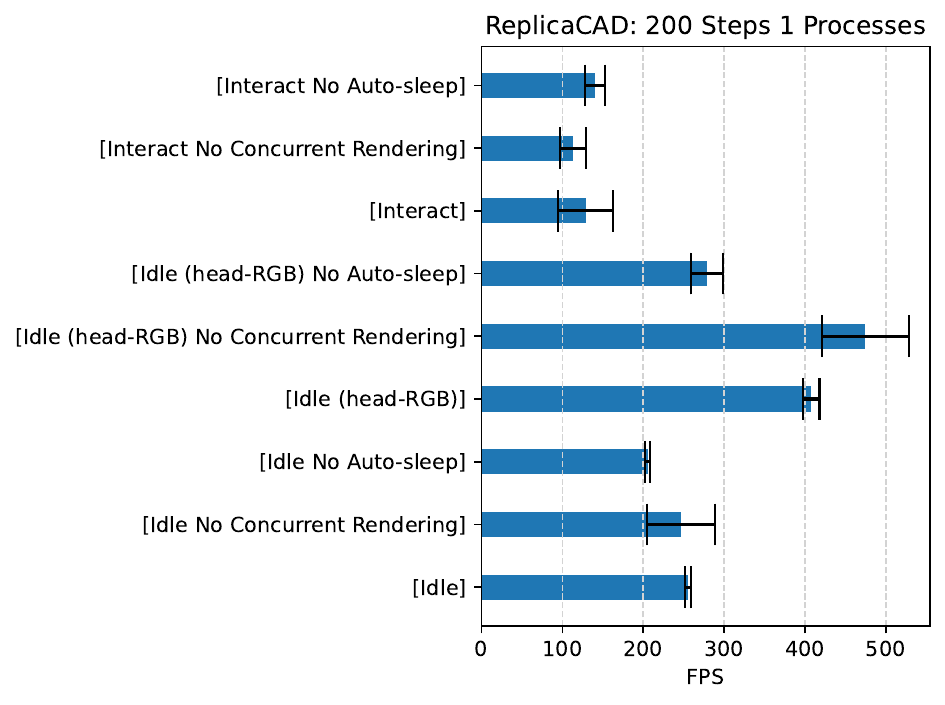

In [10]:
import subprocess
from PIL import Image
from IPython.display import display

pdf = "/content/habitat-lab-v033/data/profile/opts_1.pdf"
png_prefix = "/content/habitat-lab-v033/data/profile/opts_1_hab2"
png = png_prefix + "-1.png"

if subprocess.call(["which", "pdftoppm"], stdout=subprocess.DEVNULL) != 0:
    subprocess.run(["apt-get", "install", "-y", "-q", "poppler-utils"], check=True)

subprocess.run(["pdftoppm", "-png", "-r", "150", pdf, png_prefix], check=True)
display(Image.open(png))